### Checking quality of chrY analysis 

In [1]:
import pandas as pd

In [7]:
# read in direct pairwise
direct_file="/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/distance_matrices/chrY_072326_r2_QC_v2_centrolign_pairwise_distance.csv"

direct_df = pd.read_csv(
    direct_file,
    header=None,
    names=['sample1', 'sample2', 'distance']
)
print(direct_df.shape)
direct_df.head()


(990, 3)


,sample1,sample2,distance
0,NA18983.1,NA20850.1,0.963201
1,HG00609.1,NA18967.1,0.935376
2,NA18944.1,NA20806.1,0.948786
3,HG01192.1,HG01261.1,0.935948
4,HG01261.1,NA18944.1,0.947916


In [8]:
# read in induced pairwise 
induced_file="/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/MSA/chrY_072326/chrY_072326_r2_QC_v2_centrolign_induced_pairwise_distance.csv"

induced_df = pd.read_csv(
    induced_file,
    header=None,
    names=['sample1', 'sample2', 'distance']
)
print(induced_df.shape)
induced_df.head()

(990, 3)


,sample1,sample2,distance
0,NA18983.1,NA20850.1,0.982146
1,NA18944.1,NA20806.1,0.974965
2,HG01192.1,HG01261.1,0.963574
3,NA20827.1,NA20805.1,0.306586
4,NA18952.1,HG02391.1,0.972218


In [9]:
def make_pair_key(df):
    df = df.copy()
    df['pair_key'] = df.apply(lambda r: tuple(sorted([r['sample1'], r['sample2']])), axis=1)
    return df

induced_df = make_pair_key(induced_df).rename(columns={'distance': 'induced'})
direct_df  = make_pair_key(direct_df).rename(columns={'distance': 'direct'})

merged_df = induced_df[['pair_key', 'induced']].merge(
    direct_df[['pair_key', 'direct']],
    on='pair_key', how='inner'
)

# unpack pair_key back to sample columns
merged_df['sample1'] = merged_df['pair_key'].apply(lambda x: x[0])
merged_df['sample2'] = merged_df['pair_key'].apply(lambda x: x[1])
merged_df = merged_df[['sample1', 'sample2', 'induced', 'direct']].reset_index(drop=True)

print(merged_df.shape)
merged_df.head()


(990, 4)


,sample1,sample2,induced,direct
0,NA18983.1,NA20850.1,0.982146,0.963201
1,NA18944.1,NA20806.1,0.974965,0.948786
2,HG01192.1,HG01261.1,0.963574,0.935948
3,NA20805.1,NA20827.1,0.306586,0.273852
4,HG02391.1,NA18952.1,0.972218,0.982191


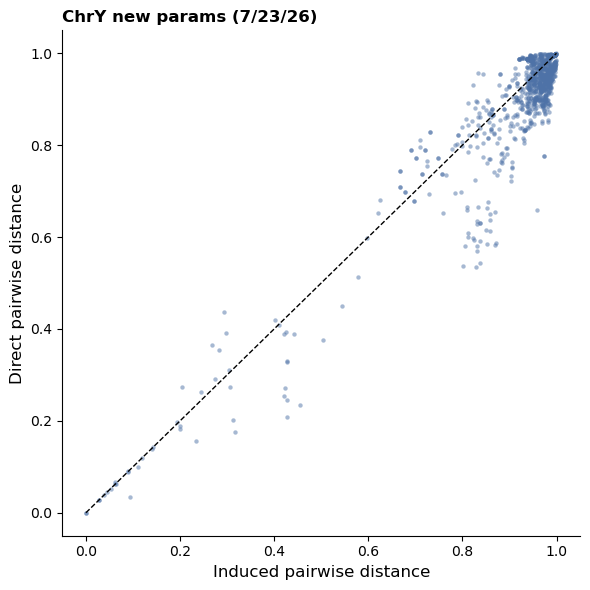

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(merged_df['induced'], merged_df['direct'],
           s=10, alpha=0.5, color='#4E72A7', linewidths=0)

# diagonal reference line
lim_min = min(merged_df['induced'].min(), merged_df['direct'].min())
lim_max = max(merged_df['induced'].max(), merged_df['direct'].max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], color='black', lw=1, linestyle='--')

ax.set_xlabel('Induced pairwise distance', fontsize=12)
ax.set_ylabel('Direct pairwise distance', fontsize=12)
ax.set_title('ChrY new params (7/23/26)', fontsize=12, fontweight='bold', loc='left')

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [6]:
merged_df[
    ((merged_df['sample1'] == 'HG03098.1') & (merged_df['sample2'] == 'NA20806.1')) |
    ((merged_df['sample1'] == 'NA20806.1') & (merged_df['sample2'] == 'HG03098.1'))
]


,sample1,sample2,induced,direct
824,HG03098.1,NA20806.1,0.871184,0.871184
